In [1]:
from mpasviewer import scvtmesh
from earthcmap import escmap
import cartopy.crs as ccrs

In [2]:
path2data = 'sample_data'

mpasd = scvtmesh(grid_file=f'{path2data}/MPAS_I_SOwISC12to60E2r4/seaice.SOwISC12to60E2r4.210107.nc', 
                 diag_list=f'{path2data}/MPAS_I_SOwISC12to60E2r4/mpassi.SOwISC12to60E2r4.rstFromG-anvil.210203.nc')

In [ ]:
mpasd.dataset()

In [4]:
dta = mpasd.load()

In [5]:
dta

<xarray.Dataset> Size: 149MB
Dimensions:                       (node: 1153614, edge: 1723935, face: 569915,
                                   time: 1, nmax_face: 7)
Coordinates:
    node_x                        (node) float64 9MB -169.3 -149.4 ... 0.695
    node_y                        (node) float64 9MB -71.13 -75.46 ... -53.5
    edge_x                        (edge) float64 14MB 19.6 71.77 ... 46.98 46.98
    edge_y                        (edge) float64 14MB -62.23 -67.93 ... -65.45
    face_x                        (face) float64 5MB -112.8 36.05 ... 0.5844
    face_y                        (face) float64 5MB 89.97 -26.58 ... -53.48
  * time                          (time) datetime64[s] 8B 1970-01-01
Dimensions without coordinates: node, edge, face, nmax_face
Data variables: (12/17)
    mesh2d                        int64 8B 0
    projected_coordinate_system   int64 8B 0
    face_nodes                    (face, nmax_face) int64 32MB 527889 ... -1
    freezeOnset                   (time, face) float64 5MB 1.0 0.0 ... 0.0 0.0
    snowfallRate                  (time, face) float64 5MB 7.247e-06 0.0 ... 0.0
    solarZenithAngleCosine        (time, face) float64 5MB -0.2991 ... -0.3273
    ...                            ...
    oceanStressCellU              (time, face) float64 5MB -0.08261 0.0 ... 0.0
    oceanStressCellV              (time, face) float64 5MB -0.01348 0.0 ... 0.0
    seaSurfaceTemperature         (time, face) float64 5MB -1.769 ... 2.904
    freezingMeltingPotential      (time, face) float64 5MB -712.8 ... -1.071e+05
    airOceanDragCoefficientRatio  (time, face) float64 5MB 1.685e+03 0.0 ... 0.0
    landIceMask                   (time, face) int32 2MB 0 0 0 0 0 ... 0 0 0 0 0
Attributes:
    Conventions:      CF-1.12 UGRID-1.0
    model_name:       MPAS
    core_name:        Atmosphere
    source:           MPAS-A
    source_software:  MPAS-viewer
    date_created:     2026-02-21 00:43:31Z
    date_modified:    2026-02-21 00:43:31Z

In [6]:
times = [str(x) for x in dta['time'].data.astype('datetime64[s]')]
# print(*times, sep = ", ")

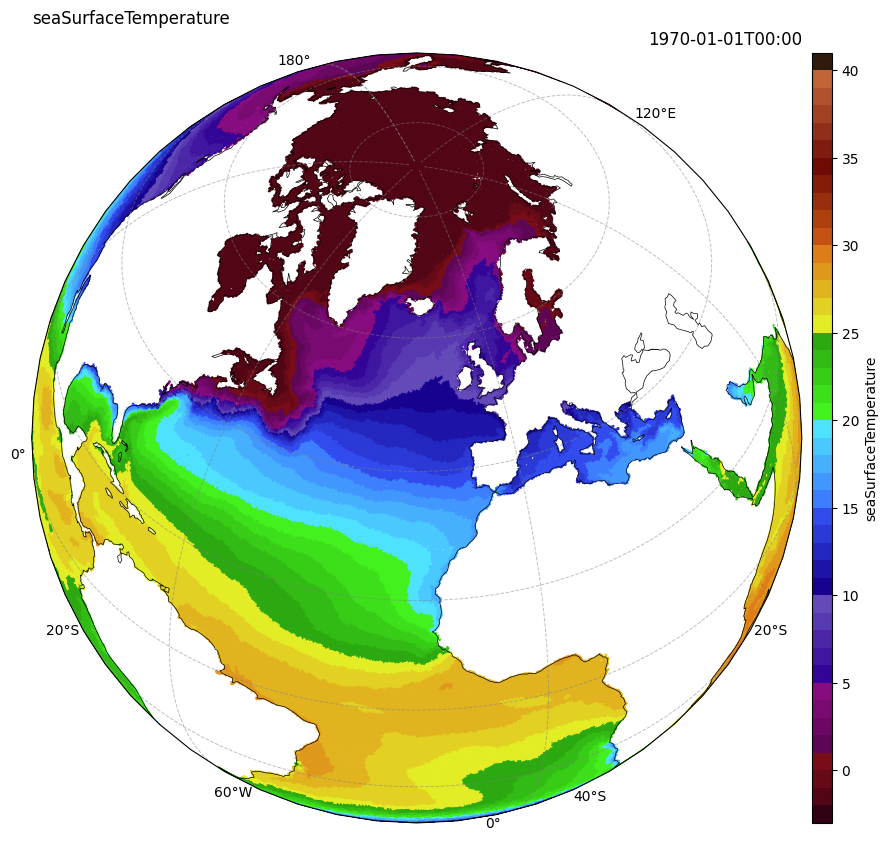

In [8]:
var1 = 'seaSurfaceTemperature'
cmap, norm = escmap("noaa_sst")
mpasd.show(dta, var_name = var1, crs=ccrs.Orthographic(central_longitude=-20, central_latitude=45), cmap = cmap, norm = norm, figsize = (10, 10))